# Recovering Images with Missing Pixels using Iterative SVD

**Authors:** Alania Lili, Dominika Petrus, Sofiia Trush


## 1. Imports

In [160]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 2. Configuration

In [ ]:
DATASET_FOLDER = "photos"     
N_IMAGES       = 15           
TARGET_SIZE    = 512  
SEED           = 42   

K_CANDIDATES         = [5, 10, 20, 30, 50, 70, 100]
PHASE_A_MISSING_RATE = 0.3
PHASE_A_ITERATIONS   = 30

MISSING_RATES = [0.1, 0.3, 0.5, 0.7]
ITER_COUNTS   = [5, 10, 20, 50]


## 3. Helper functions

Loading images, generating the mask, computing MSE / PSNR, and the mean-imputation baseline.

In [ ]:
def load_image(image_path, target_size=TARGET_SIZE):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Could not load image: {image_path}")
    image = cv2.resize(image, (target_size, target_size))
    return image.astype(float) / 255.0


def load_dataset(folder=DATASET_FOLDER, n_images=N_IMAGES):
    extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    filenames = sorted(f for f in os.listdir(folder)
                       if f.lower().endswith(extensions))
    filenames = filenames[:n_images]
    images = [load_image(os.path.join(folder, name)) for name in filenames]
    return images, filenames


In [ ]:
def generate_mask(shape, missing_rate, seed=SEED):
    rng = np.random.RandomState(seed)
    return rng.rand(*shape) > missing_rate


def corrupt_image(image, mask):
    corrupted = image.copy()
    corrupted[~mask] = 0.0
    return corrupted


In [ ]:
def compute_mse(original, recovered, mask):
    missing = ~mask
    n_missing = np.sum(missing)
    if n_missing == 0:
        return 0.0

    original_255  = original  * 255.0
    recovered_255 = recovered * 255.0

    diff = original_255[missing] - recovered_255[missing]
    return float(np.sum(diff ** 2) / n_missing)


def compute_psnr(mse):
    if mse < 1e-10:
        return float('inf')
    return 10.0 * np.log10(255.0 ** 2 / mse)


In [ ]:
def mean_imputation(corrupted, mask):
    recovered = corrupted.copy()
    mean_value = np.mean(corrupted[mask])
    recovered[~mask] = mean_value
    return recovered


## 4. Iterative truncated SVD


In [ ]:
def power_iteration_symmetric(A, n_steps=100, tol=1e-8, seed=42):
    n = A.shape[0]
    rng = np.random.default_rng(seed)
    v = rng.normal(size=n)
    v /= np.linalg.norm(v)

    for _ in range(n_steps):
        Av = A @ v
        norm_Av = np.linalg.norm(Av)
        if norm_Av < 1e-12:
            return 0.0, np.zeros(n)
        v_new = Av / norm_Av
        if np.linalg.norm(v_new - v) < tol or np.linalg.norm(v_new + v) < tol:
            v = v_new
            break
        v = v_new

    eigenvalue = float(v.T @ A @ v)
    return eigenvalue, v

def top_k_eigenpairs_symmetric(A, k, n_steps=100, tol=1e-8, seed=42):
    B = A.copy().astype(float)
    eigenvalues = []
    eigenvectors = []

    for j in range(k):
        eigenvalue, v = power_iteration_symmetric(B, n_steps=n_steps, tol=tol, seed=seed + j)
        eigenvalue = max(eigenvalue, 0.0)
        if eigenvalue < 1e-10 or np.linalg.norm(v) < 1e-12:
            break
        eigenvalues.append(eigenvalue)
        eigenvectors.append(v)
        B = B - eigenvalue * np.outer(v, v)

    if not eigenvalues:
        return np.array([]), np.zeros((A.shape[0], 0))

    return np.array(eigenvalues), np.column_stack(eigenvectors)

def iterative_svd_recovery(corrupted, mask, k, n_iterations):
    recovered = corrupted.copy()

    for step in range(n_iterations):
        AtA = recovered.T @ recovered
        eigenvalues, V = top_k_eigenpairs_symmetric(AtA, k)

        eigenvalues = np.clip(eigenvalues, 0.0, None)
        singular_values = np.sqrt(eigenvalues)

        U_columns = []
        valid_sigmas = []
        for i in range(len(singular_values)):
            sigma = singular_values[i]
            if sigma > 1e-10:
                u_i = recovered @ V[:, i] / sigma
                U_columns.append(u_i)
                valid_sigmas.append(sigma)

        if not U_columns:
            break

        U = np.column_stack(U_columns)
        sigmas = np.array(valid_sigmas)
        V = V[:, :len(valid_sigmas)]

        approximation = U @ np.diag(sigmas) @ V.T

        recovered[~mask] = approximation[~mask]
        recovered[mask] = corrupted[mask]

    return np.clip(recovered, 0.0, 1.0)

## 5. Sanity check: manual vs built-in SVD


In [ ]:
def iterative_svd_recovery_builtin(corrupted, mask, k, n_iterations):
    recovered = corrupted.copy()
    for step in range(n_iterations):
        U, s, Vt = np.linalg.svd(recovered, full_matrices=False)
        U  = U[:, :k]
        s  = s[:k]
        Vt = Vt[:k, :]
        approximation = U @ np.diag(s) @ Vt
        recovered[~mask] = approximation[~mask]
        recovered[mask]  = corrupted[mask]
    return np.clip(recovered, 0.0, 1.0)


## 6. Load the dataset

In [168]:
images, filenames = load_dataset()
print(f"Loaded {len(images)} images of shape {images[0].shape}.")
for i, name in enumerate(filenames, 1):
    print(f"  {i:2d}. {name}")


Loaded 15 images of shape (512, 512).
   1. imj11.jpg
   2. imj12.jpg
   3. imj13.jpg
   4. imj14.jpg
   5. imj15.jpg
   6. imj18.jpg
   7. imj2.jpg
   8. imj20.jpg
   9. imj3.jpg
  10. imj4.jpg
  11. imj5.jpg
  12. imj6.jpg
  13. imj7.jpg
  14. imj8.jpg
  15. imj9.jpg


### Run the sanity check

In [ ]:
test_image     = images[0]
test_mask      = generate_mask(test_image.shape, 0.3)
test_corrupted = corrupt_image(test_image, test_mask)

result_manual  = iterative_svd_recovery        (test_corrupted, test_mask, k=30, n_iterations=20)
result_builtin = iterative_svd_recovery_builtin(test_corrupted, test_mask, k=30, n_iterations=20)

difference = np.linalg.norm(result_manual - result_builtin)
print(f"Difference between manual and built-in implementations: {difference:.2e}")


Difference between manual and built-in implementations: 3.91e+00
(should be close to 0)


## 7. Find the optimal k for each image


In [ ]:
def find_optimal_k(image,
                   k_candidates=K_CANDIDATES,
                   missing_rate=PHASE_A_MISSING_RATE,
                   n_iterations=PHASE_A_ITERATIONS,
                   seed=SEED):
    mask      = generate_mask(image.shape, missing_rate, seed)
    corrupted = corrupt_image(image, mask)

    psnr_per_k = {}
    for k in k_candidates:
        recovered = iterative_svd_recovery(corrupted, mask, k, n_iterations)
        mse  = compute_mse(image, recovered, mask)
        psnr = compute_psnr(mse)
        psnr_per_k[k] = psnr

    best_k = max(psnr_per_k, key=psnr_per_k.get)
    return best_k, psnr_per_k


In [171]:
optimal_k    = {}
psnr_curves  = {} 

for name, image in zip(filenames, images):
    best_k, curve = find_optimal_k(image)
    optimal_k[name]   = best_k
    psnr_curves[name] = curve
    print(f"{name:30s}  optimal k = {best_k:3d}   PSNR = {curve[best_k]:.2f} dB")


imj11.jpg                       optimal k =  30   PSNR = 24.46 dB
imj12.jpg                       optimal k =  30   PSNR = 26.07 dB
imj13.jpg                       optimal k =  30   PSNR = 30.05 dB
imj14.jpg                       optimal k =  20   PSNR = 31.48 dB
imj15.jpg                       optimal k =  20   PSNR = 30.34 dB
imj18.jpg                       optimal k =  50   PSNR = 29.13 dB
imj2.jpg                        optimal k =  30   PSNR = 27.47 dB
imj20.jpg                       optimal k =  30   PSNR = 27.60 dB
imj3.jpg                        optimal k =  50   PSNR = 26.91 dB
imj4.jpg                        optimal k =  30   PSNR = 27.05 dB
imj5.jpg                        optimal k =  30   PSNR = 30.80 dB
imj6.jpg                        optimal k =  20   PSNR = 25.13 dB
imj7.jpg                        optimal k =  10   PSNR = 34.00 dB
imj8.jpg                        optimal k =  30   PSNR = 29.03 dB
imj9.jpg                        optimal k =  50   PSNR = 28.16 dB


### Plot: PSNR vs k

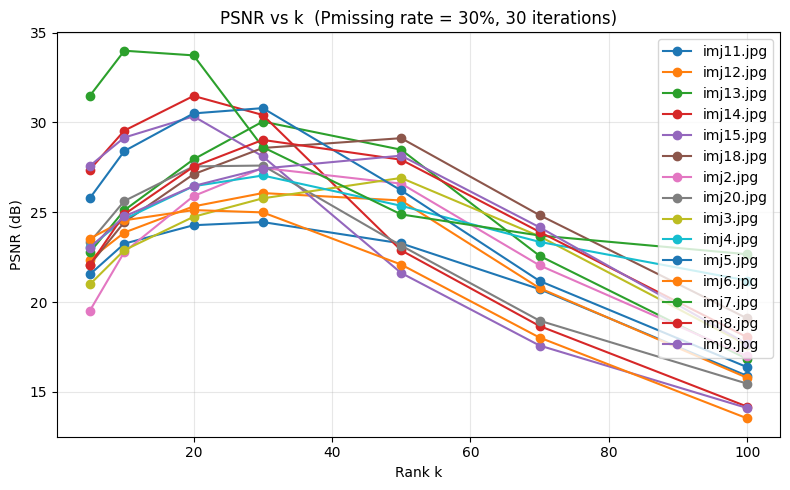

In [172]:
plt.figure(figsize=(8, 5))
for name in filenames:
    ks    = list(psnr_curves[name].keys())
    psnrs = list(psnr_curves[name].values())
    plt.plot(ks, psnrs, marker='o', label=name)

plt.xlabel("Rank k")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs k  (Pmissing rate = 30%, 30 iterations)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Singular value decay


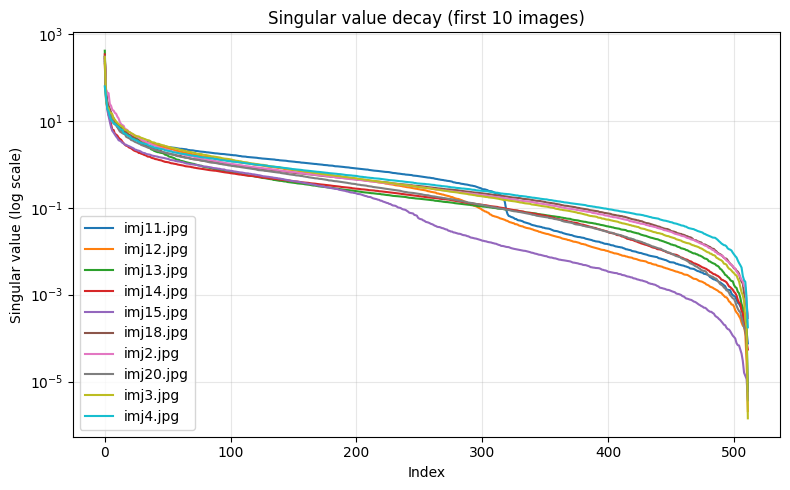

In [173]:
plt.figure(figsize=(8, 5))
for name, image in list(zip(filenames, images))[:10]:
    s = np.linalg.svd(image, compute_uv=False)
    plt.semilogy(s, label=name)

plt.xlabel("Index")
plt.ylabel("Singular value (log scale)")
plt.title("Singular value decay (first 10 images)")
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


## 9. Main experiment

In [ ]:
def run_main_experiment(images, filenames, optimal_k,
                        missing_rates=MISSING_RATES,
                        iter_counts=ITER_COUNTS,
                        seed=SEED):
    results = []
    for name, image in zip(filenames, images):
        k = optimal_k[name]
        for missing_rate in missing_rates:
            mask      = generate_mask(image.shape, missing_rate, seed)
            corrupted = corrupt_image(image, mask)
            for n_iterations in iter_counts:
                recovered = iterative_svd_recovery(corrupted, mask, k, n_iterations)
                mse  = compute_mse(image, recovered, mask)
                psnr = compute_psnr(mse)
                results.append({
                    'image':         name,
                    'k':             k,
                    'missing_rate':  missing_rate,
                    'n_iterations':  n_iterations,
                    'mse':           mse,
                    'psnr':          psnr,
                })
    return pd.DataFrame(results)


In [175]:
results_phase_b = run_main_experiment(images, filenames, optimal_k)
results_phase_b.to_csv("results_phase_b.csv", index=False)
print(f"Done. Saved {len(results_phase_b)} rows to results_phase_b.csv")
results_phase_b.head(17)


Done. Saved 240 rows to results_phase_b.csv


,image,k,missing_rate,n_iterations,mse,psnr
0,imj11.jpg,30,0.1,5,208.707717,24.935419
1,imj11.jpg,30,0.1,10,209.894822,24.910786
2,imj11.jpg,30,0.1,20,209.761985,24.913536
3,imj11.jpg,30,0.1,50,209.708446,24.914644
4,imj11.jpg,30,0.3,5,446.742339,21.630232
5,imj11.jpg,30,0.3,10,233.881818,24.440839
6,imj11.jpg,30,0.3,20,231.965244,24.476574
7,imj11.jpg,30,0.3,50,233.130672,24.454809
8,imj11.jpg,30,0.5,5,1913.020046,15.313608
9,imj11.jpg,30,0.5,10,706.911840,19.637151


### Plot: PSNR vs missing rate / MSE vs missing rate

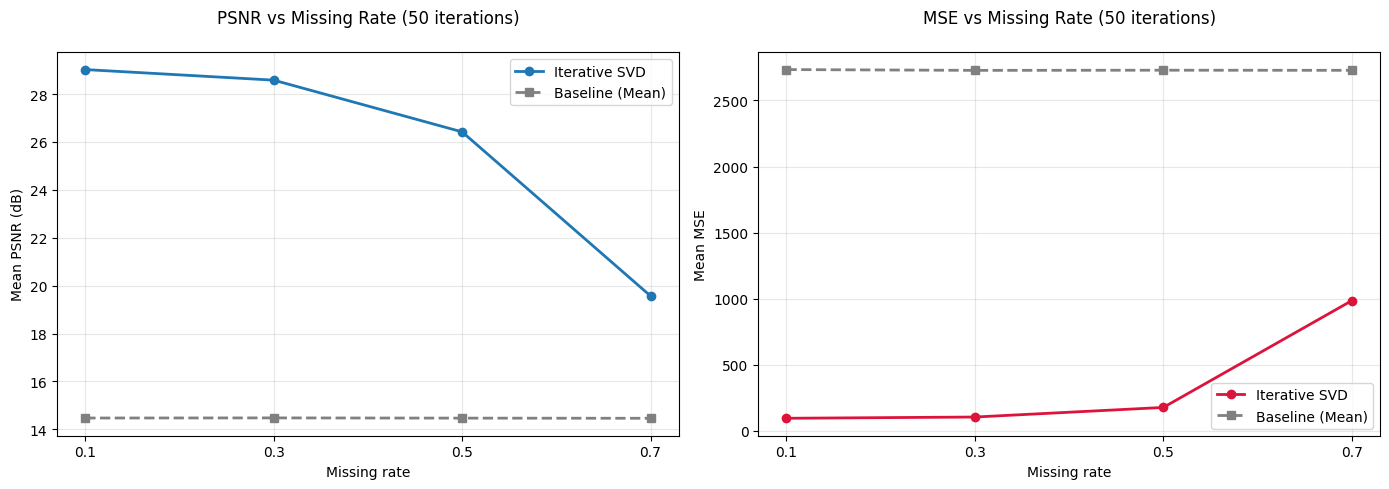

In [176]:
fixed_iter = max(ITER_COUNTS)

svd_subset = results_phase_b[results_phase_b['n_iterations'] == fixed_iter]
svd_mean_psnr = svd_subset.groupby('missing_rate')['psnr'].mean()
svd_mean_mse = svd_subset.groupby('missing_rate')['mse'].mean()

baseline_mean_psnr = results_baseline.groupby('missing_rate')['psnr'].mean()
baseline_mean_mse = results_baseline.groupby('missing_rate')['mse'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(svd_mean_psnr.index, svd_mean_psnr.values, marker='o', linewidth=2, label='Iterative SVD')
ax1.plot(baseline_mean_psnr.index, baseline_mean_psnr.values, marker='s', linewidth=2, linestyle='--', color='gray', label='Baseline (Mean)')
ax1.set_xlabel("Missing rate")
ax1.set_ylabel("Mean PSNR (dB)")
ax1.set_title(f"PSNR vs Missing Rate ({fixed_iter} iterations)\n")
ax1.set_xticks(MISSING_RATES)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(svd_mean_mse.index, svd_mean_mse.values, marker='o', linewidth=2, color='crimson', label='Iterative SVD')
ax2.plot(baseline_mean_mse.index, baseline_mean_mse.values, marker='s', linewidth=2, linestyle='--', color='gray', label='Baseline (Mean)')
ax2.set_xlabel("Missing rate")
ax2.set_ylabel("Mean MSE")
ax2.set_title(f"MSE vs Missing Rate ({fixed_iter} iterations)\n")
ax2.set_xticks(MISSING_RATES)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Baseline comparison: mean imputation


In [177]:
def run_baseline_experiment(images, filenames,
                            missing_rates=MISSING_RATES, seed=SEED):
    results = []
    for name, image in zip(filenames, images):
        for missing_rate in missing_rates:
            mask      = generate_mask(image.shape, missing_rate, seed)
            corrupted = corrupt_image(image, mask)
            recovered = mean_imputation(corrupted, mask)
            mse  = compute_mse(image, recovered, mask)
            psnr = compute_psnr(mse)
            results.append({
                'image':        name,
                'missing_rate': missing_rate,
                'mse':          mse,
                'psnr':         psnr,
            })
    return pd.DataFrame(results)


results_baseline = run_baseline_experiment(images, filenames)
results_baseline.to_csv("results_baseline.csv", index=False)
print(f"Baseline done. Saved {len(results_baseline)} rows.")


Baseline done. Saved 60 rows.


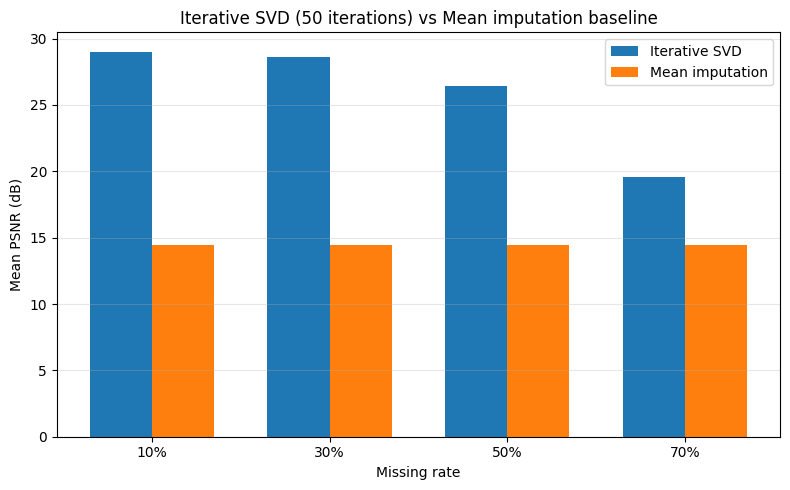

In [178]:
fixed_iter   = max(ITER_COUNTS)
svd_subset   = results_phase_b[results_phase_b['n_iterations'] == fixed_iter]
svd_mean     = svd_subset.groupby('missing_rate')['psnr'].mean()
baseline_mean = results_baseline.groupby('missing_rate')['psnr'].mean()

x     = np.arange(len(MISSING_RATES))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, svd_mean.values,      width, label='Iterative SVD')
plt.bar(x + width/2, baseline_mean.values, width, label='Mean imputation')
plt.xticks(x, [f"{int(r*100)}%" for r in MISSING_RATES])
plt.xlabel("Missing rate")
plt.ylabel("Mean PSNR (dB)")
plt.title(f"Iterative SVD ({fixed_iter} iterations) vs Mean imputation baseline")
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 11. Visual examples for three images 


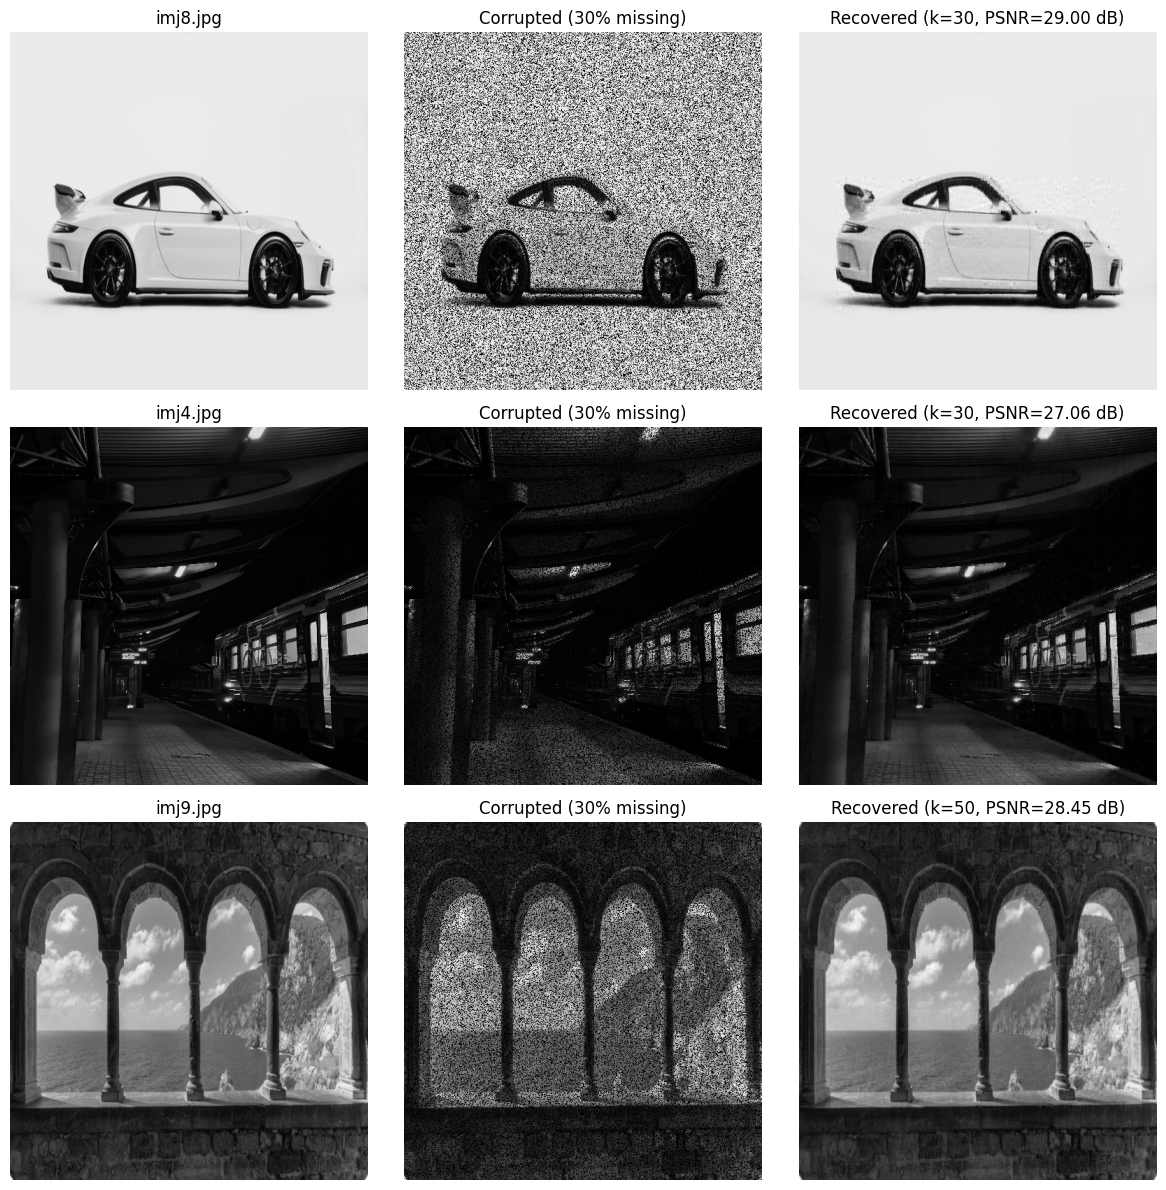

In [179]:

indices_to_show    = [13, 9, 14]
missing_rate_show  = 0.3
n_iterations_show  = max(ITER_COUNTS)

fig, axes = plt.subplots(len(indices_to_show), 3, figsize=(12, 4 * len(indices_to_show)))

for row, idx in enumerate(indices_to_show):
    image = images[idx]
    name  = filenames[idx]
    k     = optimal_k[name]

    mask      = generate_mask(image.shape, missing_rate_show, SEED)
    corrupted = corrupt_image(image, mask)
    recovered = iterative_svd_recovery(corrupted, mask, k, n_iterations_show)

    mse  = compute_mse(image, recovered, mask)
    psnr = compute_psnr(mse)

    axes[row, 0].imshow(image,     cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f"{name}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(corrupted, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title(f"Corrupted ({int(missing_rate_show*100)}% missing)")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(recovered, cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_title(f"Recovered (k={k}, PSNR={psnr:.2f} dB)")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


## 12. Summary table

In [ ]:
summary0 = (results_phase_b[results_phase_b['n_iterations'] == ITER_COUNTS[0]]
           .groupby('missing_rate')[['mse', 'psnr']]
           .mean()
           .round(3))

baseline_summary = (results_baseline
                    .groupby('missing_rate')[['mse', 'psnr']]
                    .mean()
                    .round(3))

print("Iterative SVD (5 iterations):")
print(summary0)
print()
print("Mean imputation (baseline):")
print(baseline_summary)

summary1 = (results_phase_b[results_phase_b['n_iterations'] == ITER_COUNTS[1]]
           .groupby('missing_rate')[['mse', 'psnr']]
           .mean()
           .round(3))

baseline_summary = (results_baseline
                    .groupby('missing_rate')[['mse', 'psnr']]
                    .mean()
                    .round(3))

print("Iterative SVD (10 iterations):")
print(summary1)
print()
print("Mean imputation (baseline):")
print(baseline_summary)

summary2 = (results_phase_b[results_phase_b['n_iterations'] == ITER_COUNTS[2]]
           .groupby('missing_rate')[['mse', 'psnr']]
           .mean()
           .round(3))

baseline_summary = (results_baseline
                    .groupby('missing_rate')[['mse', 'psnr']]
                    .mean()
                    .round(3))

print("Iterative SVD (20 iterations):")
print(summary2)
print()
print("Mean imputation (baseline):")
print(baseline_summary)

summary3 = (results_phase_b[results_phase_b['n_iterations'] == ITER_COUNTS[3]]
           .groupby('missing_rate')[['mse', 'psnr']]
           .mean()
           .round(3))

baseline_summary = (results_baseline
                    .groupby('missing_rate')[['mse', 'psnr']]
                    .mean()
                    .round(3))

print("Iterative SVD (50 iterations):")
print(summary3)
print()
print("Mean imputation (baseline):")
print(baseline_summary)


Iterative SVD (5 iterations):
                   mse    psnr
missing_rate                  
0.1            102.550  28.617
0.3            385.231  23.207
0.5           1662.004  16.958
0.7           5330.162  12.038

Mean imputation (baseline):
                   mse    psnr
missing_rate                  
0.1           2733.581  14.474
0.3           2727.546  14.479
0.5           2728.741  14.470
0.7           2727.851  14.463
Iterative SVD (10 iterations):
                   mse    psnr
missing_rate                  
0.1             95.212  29.015
0.3            152.764  27.014
0.5            643.712  21.090
0.7           3122.286  14.242

Mean imputation (baseline):
                   mse    psnr
missing_rate                  
0.1           2733.581  14.474
0.3           2727.546  14.479
0.5           2728.741  14.470
0.7           2727.851  14.463
Iterative SVD (20 iterations):
                   mse    psnr
missing_rate                  
0.1             95.172  29.021
0.3          

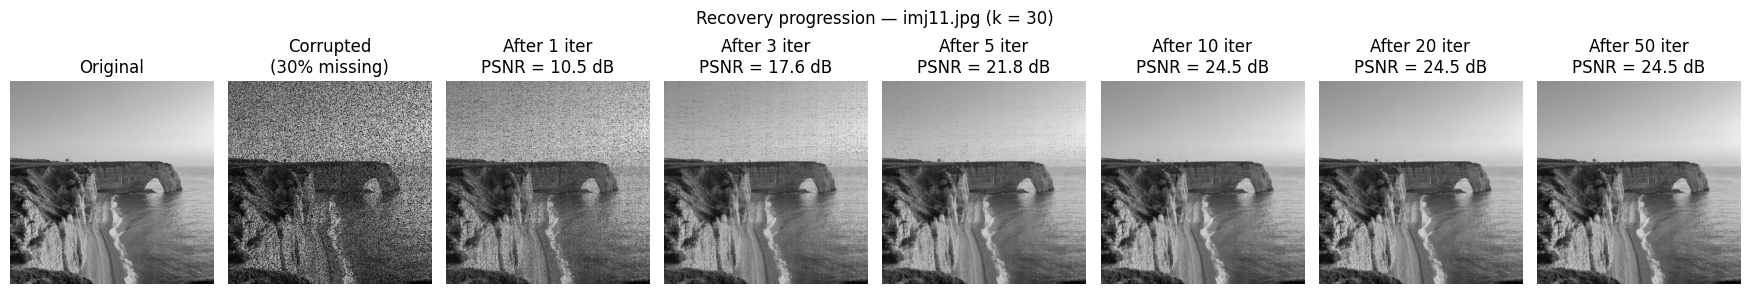

In [181]:
progression_image_idx = 0  
progression_missing   = 0.3
checkpoints           = [1, 3, 5, 10, 20, 50] 

image = images[progression_image_idx]
name  = filenames[progression_image_idx]
k     = optimal_k[name]

mask      = generate_mask(image.shape, progression_missing, SEED)
corrupted = corrupt_image(image, mask)

snapshots = {}
recovered = corrupted.copy()
prev_iter = 0
for n_iter in checkpoints:
    extra_iters = n_iter - prev_iter
    recovered = iterative_svd_recovery(recovered, mask, k, extra_iters)
    snapshots[n_iter] = recovered.copy()
    prev_iter = n_iter

n_panels = 2 + len(checkpoints)
fig, axes = plt.subplots(1, n_panels, figsize=(2.2 * n_panels, 3))

axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(corrupted, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Corrupted\n({int(progression_missing*100)}% missing)")
axes[1].axis('off')

for ax, n_iter in zip(axes[2:], checkpoints):
    snapshot = snapshots[n_iter]
    mse = compute_mse(image, snapshot, mask)
    psnr = compute_psnr(mse)
    ax.imshow(snapshot, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"After {n_iter} iter\nPSNR = {psnr:.1f} dB")
    ax.axis('off')

plt.suptitle(f"Recovery progression — {name} (k = {k})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

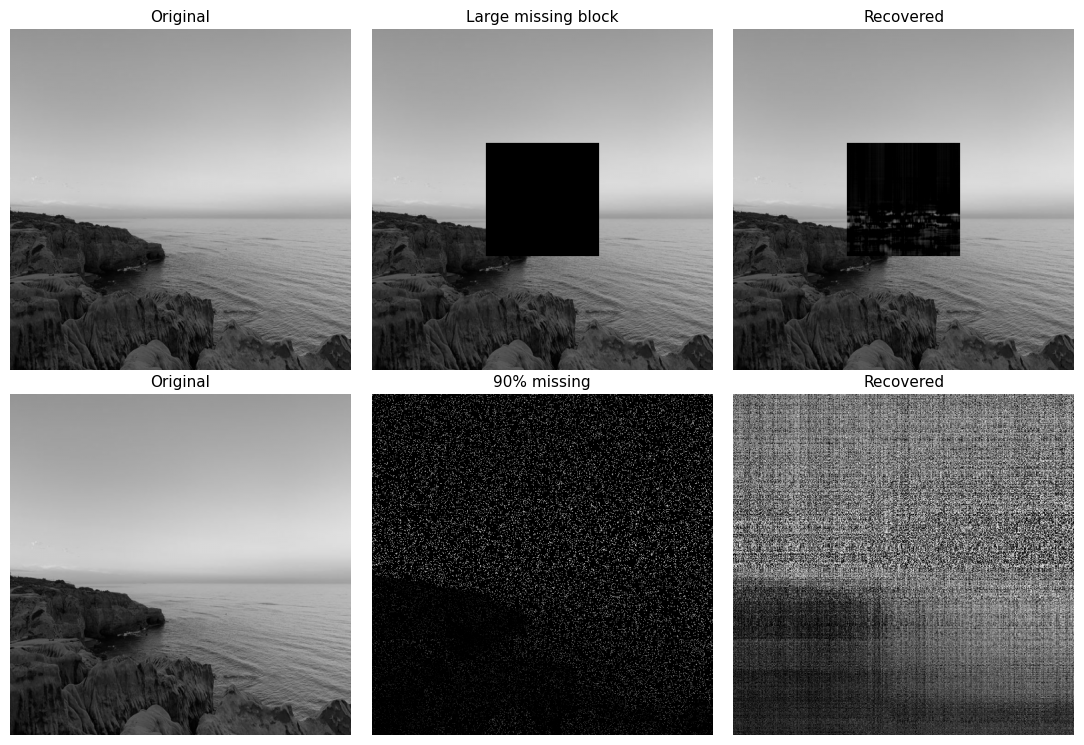

In [ ]:
failure_image_idx = 4
image = images[failure_image_idx]
name  = filenames[failure_image_idx]
k     = optimal_k[name]

block_mask = np.ones(image.shape, dtype=bool)
h, w = image.shape
block_h, block_w = h // 3, w // 3
top  = (h - block_h) // 2
left = (w - block_w) // 2
block_mask[top:top + block_h, left:left + block_w] = False

corrupted_block = corrupt_image(image, block_mask)
recovered_block = iterative_svd_recovery(corrupted_block, block_mask, k, n_iterations=50)


extreme_missing = 0.9
extreme_mask      = generate_mask(image.shape, extreme_missing, SEED)
corrupted_extreme = corrupt_image(image, extreme_mask)
recovered_extreme = iterative_svd_recovery(corrupted_extreme, extreme_mask, k, n_iterations=50)

psnr_extreme = compute_psnr(compute_mse(image, recovered_extreme, extreme_mask))


fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))

axes[0, 0].imshow(image,           cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("Original", fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(corrupted_block, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title("Large missing block", fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].imshow(recovered_block, cmap='gray', vmin=0, vmax=1)
axes[0, 2].set_title("Recovered", fontsize=11)
axes[0, 2].axis('off')

axes[1, 0].imshow(image,             cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title("Original", fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(corrupted_extreme, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title("90% missing", fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(recovered_extreme, cmap='gray', vmin=0, vmax=1)
axes[1, 2].set_title(f"Recovered", fontsize=11)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()